In [1]:
from pathlib import Path 

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scienceplots
import numpy as np

plt.style.use(['ieee', 'nature'])

%matplotlib inline

In [2]:
dir = Path('./data/')
dir

PosixPath('data')

In [3]:
afesurveydf = pd.read_csv(dir/'us_multiplexing_afe_survey.csv')
afesurveydf

,Group,Work,Tech Node,Raw RF Data Access,Architecture,Framerate-Channel Reduction Tradeoff,Output Driver Bandwidth-Channel Reduction Tradeoff,Framerate (FPS),Power Dissipation/Elem. (mW),Active Area/Elem. (mm^2),...,Noise Averaging,IRNC ($pA/\sqrt{Hz}$),IRNV ($nV/\sqrt{Hz}$),IRNA ($mPa/\sqrt{Hz}$),Center Freq. F0 (MHz),-3dB BW (MHz),Input Dynamic Range (dB),SNR / SNDR (dB),DOI,Notes
0,EI-TUDelft,NurielJSSC2025,180nm BCD-CMOS,No,2x2:µBF & 2x1:A-TDM,Yes,Yes,<2000,0.950,0.1200,...,Yes,NR,NR,0.452,2.5,2.4,73,52.0,https://doi.org/10.1109/JSSC.2025.3534087,NR
1,EI-TUDelft,YHopfJSSC2024,180nm BCD-CMOS,No,3x1:µBF & 6x1:D-TDM,Yes,Yes,<=1000,1.120,0.0300,...,Yes,NR,NR,0.6,4.0,9.8,X,52.2,https://doi.org/10.1109/JSSC.2023.3299749,NR
2,SCEE-GIT,ARezvanitabarTBCAS2022,180nm BCD-HVCMOS,No,5x1:µBF & 8x1:A-TDM,Yes,Yes,<=1000,4.650,0.1500,...,Yes,NR,8.6,NR,5.0,12.0,76,NaN,https://doi.org/10.1109/TBCAS.2022.3205024,NR
3,EI-TUDelft,CChenJSSC2018,180nm BCD-CMOS,No,9x1:µBF & 4x1:D-TDM,Yes,Yes,<1000,0.910,0.0260,...,Yes,NR,6.3,NR,5.0,11.9,84,51.8,https://doi.org/10.1109/JSSC.2018.2864295,NR
4,EI-TUDelft,PGuoJSSC2024,180nm BCD-CMOS,No,2x2:µBF & 8x1:A-TDM & 4:1:D-PAM DL & SAI,Yes,Yes,<1000,1.830,0.0480,...,Yes,0.7,NR,NR,9.0,14.3,83,NaN,https://doi.org/10.1109/JSSC.2024.3355854,PAM scheme to allow for a very high compressio...
5,ButterflyIQ,JRothbergPNAS2021,130nm BCD-MEMS,Yes,8x1:CES & 4x1:D-TDM,No,Yes,>2000,0.900,0.0430,...,Yes,NR,NR,0.5,5.0,10.7,85,NaN,https://doi.org/10.1073/pnas.2019339118,Originated the first Butterfly IQ handeld stat...
6,SME/SCEE-GIT,TCarpenterTUFFC2016,350nm 2P4M,Yes,8x1:A-TDM,No,Yes,<2000,0.480,0.2080,...,No,NR,NR,NR,7.0,5.0,X,NaN,https://doi.org/10.1109/TUFFC.2016.2557622,NR
7,ME/SCEE-GIT,MRashidULTSYM2014,350nm CMOS,Yes,8x1:A-OFDM,No,Yes,>1000,7.250,0.1540,...,Yes,16,NR,NR,7.0,20.0,X,NaN,https://doi.org/10.1109/ULTSYM.2014.0381,The TIA's bandwidth is simulated only from pos...
8,MITUS-TUD,DDias2026,28nm TSMC CMOS,Yes,8x1:CMUX,No,No,>1000,0.560,0.0198,...,Yes,NR,5.2,NR,2.0,25.0,NaN,NaN,NaN,Post Layout Sim. Results This work
9,CTI-Hitachi,YIgarashiJSSC2019,180nm HV SOI CMOS,No,24x1:µBF,Yes,No,<1000,0.740,0.0900,...,Yes,NR,NR,NR,2.5,6.5,85,NaN,https://doi.org/10.1109/JSSC.2019.2921697,"Does not indicate SNDR, SNR, input referred no..."


In [4]:

afesurveydf['Input Dynamic Range (dB)'] = pd.to_numeric(afesurveydf['Input Dynamic Range (dB)'], errors='coerce')
afesurveydf['Input Dynamic Range (dB)'] = afesurveydf['Input Dynamic Range (dB)'].fillna(afesurveydf['Input Dynamic Range (dB)'].mean())
afesurveydf['Active Area/Elem. (mm^2)'] = afesurveydf['Active Area/Elem. (mm^2)'].astype(float)
afesurveydf['FPS (Hz)'] = afesurveydf['Framerate (FPS)'].apply(lambda x: '$\leq$1000' if ('<=1000' in x or '<1000' in x) else '>1000')
afesurveydf['Architecture'] = afesurveydf['Architecture'].apply(lambda x: 'µBF & TDM' if ('µBF' in x and 'TDM' in x) else 'FDM' if('FDM' in x) else 'CES' if 'CES' in x else 'SAI' if 'SAI' in x else 'TDM')
afesurveydf['Nr. Channels/ $mm^2$'] = afesurveydf['Active Area/Elem. (mm^2)'].apply(lambda x: 1/x)
afesurveydf

,Group,Work,Tech Node,Raw RF Data Access,Architecture,Framerate-Channel Reduction Tradeoff,Output Driver Bandwidth-Channel Reduction Tradeoff,Framerate (FPS),Power Dissipation/Elem. (mW),Active Area/Elem. (mm^2),...,IRNV ($nV/\sqrt{Hz}$),IRNA ($mPa/\sqrt{Hz}$),Center Freq. F0 (MHz),-3dB BW (MHz),Input Dynamic Range (dB),SNR / SNDR (dB),DOI,Notes,FPS (Hz),Nr. Channels/ $mm^2$
0,EI-TUDelft,NurielJSSC2025,180nm BCD-CMOS,No,µBF & TDM,Yes,Yes,<2000,0.950,0.1200,...,NR,0.452,2.5,2.4,73.000000,52.0,https://doi.org/10.1109/JSSC.2025.3534087,NR,>1000,8.333333
1,EI-TUDelft,YHopfJSSC2024,180nm BCD-CMOS,No,µBF & TDM,Yes,Yes,<=1000,1.120,0.0300,...,NR,0.6,4.0,9.8,73.038462,52.2,https://doi.org/10.1109/JSSC.2023.3299749,NR,$\leq$1000,33.333333
2,SCEE-GIT,ARezvanitabarTBCAS2022,180nm BCD-HVCMOS,No,µBF & TDM,Yes,Yes,<=1000,4.650,0.1500,...,8.6,NR,5.0,12.0,76.000000,NaN,https://doi.org/10.1109/TBCAS.2022.3205024,NR,$\leq$1000,6.666667
3,EI-TUDelft,CChenJSSC2018,180nm BCD-CMOS,No,µBF & TDM,Yes,Yes,<1000,0.910,0.0260,...,6.3,NR,5.0,11.9,84.000000,51.8,https://doi.org/10.1109/JSSC.2018.2864295,NR,$\leq$1000,38.461538
4,EI-TUDelft,PGuoJSSC2024,180nm BCD-CMOS,No,µBF & TDM,Yes,Yes,<1000,1.830,0.0480,...,NR,NR,9.0,14.3,83.000000,NaN,https://doi.org/10.1109/JSSC.2024.3355854,PAM scheme to allow for a very high compressio...,$\leq$1000,20.833333
5,ButterflyIQ,JRothbergPNAS2021,130nm BCD-MEMS,Yes,CES,No,Yes,>2000,0.900,0.0430,...,NR,0.5,5.0,10.7,85.000000,NaN,https://doi.org/10.1073/pnas.2019339118,Originated the first Butterfly IQ handeld stat...,>1000,23.255814
6,SME/SCEE-GIT,TCarpenterTUFFC2016,350nm 2P4M,Yes,TDM,No,Yes,<2000,0.480,0.2080,...,NR,NR,7.0,5.0,73.038462,NaN,https://doi.org/10.1109/TUFFC.2016.2557622,NR,>1000,4.807692
7,ME/SCEE-GIT,MRashidULTSYM2014,350nm CMOS,Yes,FDM,No,Yes,>1000,7.250,0.1540,...,NR,NR,7.0,20.0,73.038462,NaN,https://doi.org/10.1109/ULTSYM.2014.0381,The TIA's bandwidth is simulated only from pos...,>1000,6.493506
8,MITUS-TUD,DDias2026,28nm TSMC CMOS,Yes,TDM,No,No,>1000,0.560,0.0198,...,5.2,NR,2.0,25.0,73.038462,NaN,NaN,Post Layout Sim. Results This work,>1000,50.505051
9,CTI-Hitachi,YIgarashiJSSC2019,180nm HV SOI CMOS,No,TDM,Yes,No,<1000,0.740,0.0900,...,NR,NR,2.5,6.5,85.000000,NaN,https://doi.org/10.1109/JSSC.2019.2921697,"Does not indicate SNDR, SNR, input referred no...",$\leq$1000,11.111111


In [5]:
# introduce noise efficiency factor taking into acount only the power dissipation and the -3dB bandwidth
afesurveydf['FoM$_{MUX}$ (dB)'] = afesurveydf['Input Dynamic Range (dB)']  + 10 * np.log10( afesurveydf['Ch. Compression Ratio'] / (afesurveydf['Clock Speed (MHz)'] * afesurveydf['Power Dissipation/Elem. (mW)']))
afesurveydf

,Group,Work,Tech Node,Raw RF Data Access,Architecture,Framerate-Channel Reduction Tradeoff,Output Driver Bandwidth-Channel Reduction Tradeoff,Framerate (FPS),Power Dissipation/Elem. (mW),Active Area/Elem. (mm^2),...,IRNA ($mPa/\sqrt{Hz}$),Center Freq. F0 (MHz),-3dB BW (MHz),Input Dynamic Range (dB),SNR / SNDR (dB),DOI,Notes,FPS (Hz),Nr. Channels/ $mm^2$,FoM$_{MUX}$ (dB)
0,EI-TUDelft,NurielJSSC2025,180nm BCD-CMOS,No,µBF & TDM,Yes,Yes,<2000,0.950,0.1200,...,0.452,2.5,2.4,73.000000,52.0,https://doi.org/10.1109/JSSC.2025.3534087,NR,>1000,8.333333,64.294864
1,EI-TUDelft,YHopfJSSC2024,180nm BCD-CMOS,No,µBF & TDM,Yes,Yes,<=1000,1.120,0.0300,...,0.6,4.0,9.8,73.038462,52.2,https://doi.org/10.1109/JSSC.2023.3299749,NR,$\leq$1000,33.333333,61.296894
2,SCEE-GIT,ARezvanitabarTBCAS2022,180nm BCD-HVCMOS,No,µBF & TDM,Yes,Yes,<=1000,4.650,0.1500,...,NR,5.0,12.0,76.000000,NaN,https://doi.org/10.1109/TBCAS.2022.3205024,NR,$\leq$1000,6.666667,62.335770
3,EI-TUDelft,CChenJSSC2018,180nm BCD-CMOS,No,µBF & TDM,Yes,Yes,<1000,0.910,0.0260,...,NR,5.0,11.9,84.000000,51.8,https://doi.org/10.1109/JSSC.2018.2864295,NR,$\leq$1000,38.461538,85.201399
4,EI-TUDelft,PGuoJSSC2024,180nm BCD-CMOS,No,µBF & TDM,Yes,Yes,<1000,1.830,0.0480,...,NR,9.0,14.3,83.000000,NaN,https://doi.org/10.1109/JSSC.2024.3355854,PAM scheme to allow for a very high compressio...,$\leq$1000,20.833333,68.614577
5,ButterflyIQ,JRothbergPNAS2021,130nm BCD-MEMS,Yes,CES,No,Yes,>2000,0.900,0.0430,...,0.5,5.0,10.7,85.000000,NaN,https://doi.org/10.1073/pnas.2019339118,Originated the first Butterfly IQ handeld stat...,>1000,23.255814,78.467875
6,SME/SCEE-GIT,TCarpenterTUFFC2016,350nm 2P4M,Yes,TDM,No,Yes,<2000,0.480,0.2080,...,NR,7.0,5.0,73.038462,NaN,https://doi.org/10.1109/TUFFC.2016.2557622,NR,>1000,4.807692,62.246649
7,ME/SCEE-GIT,MRashidULTSYM2014,350nm CMOS,Yes,FDM,No,Yes,>1000,7.250,0.1540,...,NR,7.0,20.0,73.038462,NaN,https://doi.org/10.1109/ULTSYM.2014.0381,The TIA's bandwidth is simulated only from pos...,>1000,6.493506,48.414482
8,MITUS-TUD,DDias2026,28nm TSMC CMOS,Yes,TDM,No,No,>1000,0.560,0.0198,...,NR,2.0,25.0,73.038462,NaN,NaN,Post Layout Sim. Results This work,>1000,50.505051,67.597781
9,CTI-Hitachi,YIgarashiJSSC2019,180nm HV SOI CMOS,No,TDM,Yes,No,<1000,0.740,0.0900,...,NR,2.5,6.5,85.000000,NaN,https://doi.org/10.1109/JSSC.2019.2921697,"Does not indicate SNDR, SNR, input referred no...",$\leq$1000,11.111111,84.089195


In [6]:
afesurveydf['PaperID'] = afesurveydf['Work'].str.extract(r'([A-Z]{4,7}\d{4})$')
afesurveydf

,Group,Work,Tech Node,Raw RF Data Access,Architecture,Framerate-Channel Reduction Tradeoff,Output Driver Bandwidth-Channel Reduction Tradeoff,Framerate (FPS),Power Dissipation/Elem. (mW),Active Area/Elem. (mm^2),...,Center Freq. F0 (MHz),-3dB BW (MHz),Input Dynamic Range (dB),SNR / SNDR (dB),DOI,Notes,FPS (Hz),Nr. Channels/ $mm^2$,FoM$_{MUX}$ (dB),PaperID
0,EI-TUDelft,NurielJSSC2025,180nm BCD-CMOS,No,µBF & TDM,Yes,Yes,<2000,0.950,0.1200,...,2.5,2.4,73.000000,52.0,https://doi.org/10.1109/JSSC.2025.3534087,NR,>1000,8.333333,64.294864,JSSC2025
1,EI-TUDelft,YHopfJSSC2024,180nm BCD-CMOS,No,µBF & TDM,Yes,Yes,<=1000,1.120,0.0300,...,4.0,9.8,73.038462,52.2,https://doi.org/10.1109/JSSC.2023.3299749,NR,$\leq$1000,33.333333,61.296894,JSSC2024
2,SCEE-GIT,ARezvanitabarTBCAS2022,180nm BCD-HVCMOS,No,µBF & TDM,Yes,Yes,<=1000,4.650,0.1500,...,5.0,12.0,76.000000,NaN,https://doi.org/10.1109/TBCAS.2022.3205024,NR,$\leq$1000,6.666667,62.335770,TBCAS2022
3,EI-TUDelft,CChenJSSC2018,180nm BCD-CMOS,No,µBF & TDM,Yes,Yes,<1000,0.910,0.0260,...,5.0,11.9,84.000000,51.8,https://doi.org/10.1109/JSSC.2018.2864295,NR,$\leq$1000,38.461538,85.201399,JSSC2018
4,EI-TUDelft,PGuoJSSC2024,180nm BCD-CMOS,No,µBF & TDM,Yes,Yes,<1000,1.830,0.0480,...,9.0,14.3,83.000000,NaN,https://doi.org/10.1109/JSSC.2024.3355854,PAM scheme to allow for a very high compressio...,$\leq$1000,20.833333,68.614577,JSSC2024
5,ButterflyIQ,JRothbergPNAS2021,130nm BCD-MEMS,Yes,CES,No,Yes,>2000,0.900,0.0430,...,5.0,10.7,85.000000,NaN,https://doi.org/10.1073/pnas.2019339118,Originated the first Butterfly IQ handeld stat...,>1000,23.255814,78.467875,PNAS2021
6,SME/SCEE-GIT,TCarpenterTUFFC2016,350nm 2P4M,Yes,TDM,No,Yes,<2000,0.480,0.2080,...,7.0,5.0,73.038462,NaN,https://doi.org/10.1109/TUFFC.2016.2557622,NR,>1000,4.807692,62.246649,TUFFC2016
7,ME/SCEE-GIT,MRashidULTSYM2014,350nm CMOS,Yes,FDM,No,Yes,>1000,7.250,0.1540,...,7.0,20.0,73.038462,NaN,https://doi.org/10.1109/ULTSYM.2014.0381,The TIA's bandwidth is simulated only from pos...,>1000,6.493506,48.414482,ULTSYM2014
8,MITUS-TUD,DDias2026,28nm TSMC CMOS,Yes,TDM,No,No,>1000,0.560,0.0198,...,2.0,25.0,73.038462,NaN,NaN,Post Layout Sim. Results This work,>1000,50.505051,67.597781,NaN
9,CTI-Hitachi,YIgarashiJSSC2019,180nm HV SOI CMOS,No,TDM,Yes,No,<1000,0.740,0.0900,...,2.5,6.5,85.000000,NaN,https://doi.org/10.1109/JSSC.2019.2921697,"Does not indicate SNDR, SNR, input referred no...",$\leq$1000,11.111111,84.089195,JSSC2019


In [7]:
afesurveydf = afesurveydf.drop(index=8)

In [17]:
afesurveydf.to_csv(dir / 'us_mux_afe_survey_post_processed.csv')

In [8]:
# Use the simpler, built-in MathText engine
plt.rcParams['text.usetex'] = False

In [24]:
CUSTOM_DOT_SIZE = 30 # Adjust this value (default is usually ~50)
MARKER_STYLES = ['^', 's', 'o', 'd', 'X'] # Triangle, Square, Circle, Diamond (add more as needed for your classes)
CUSTOM_COLORS = ["#1B55E8", "#FF6600", '#DC267F', '#1D3557'] # Example colors (e.g., Red, Blue, Cyan, Dark Blue)

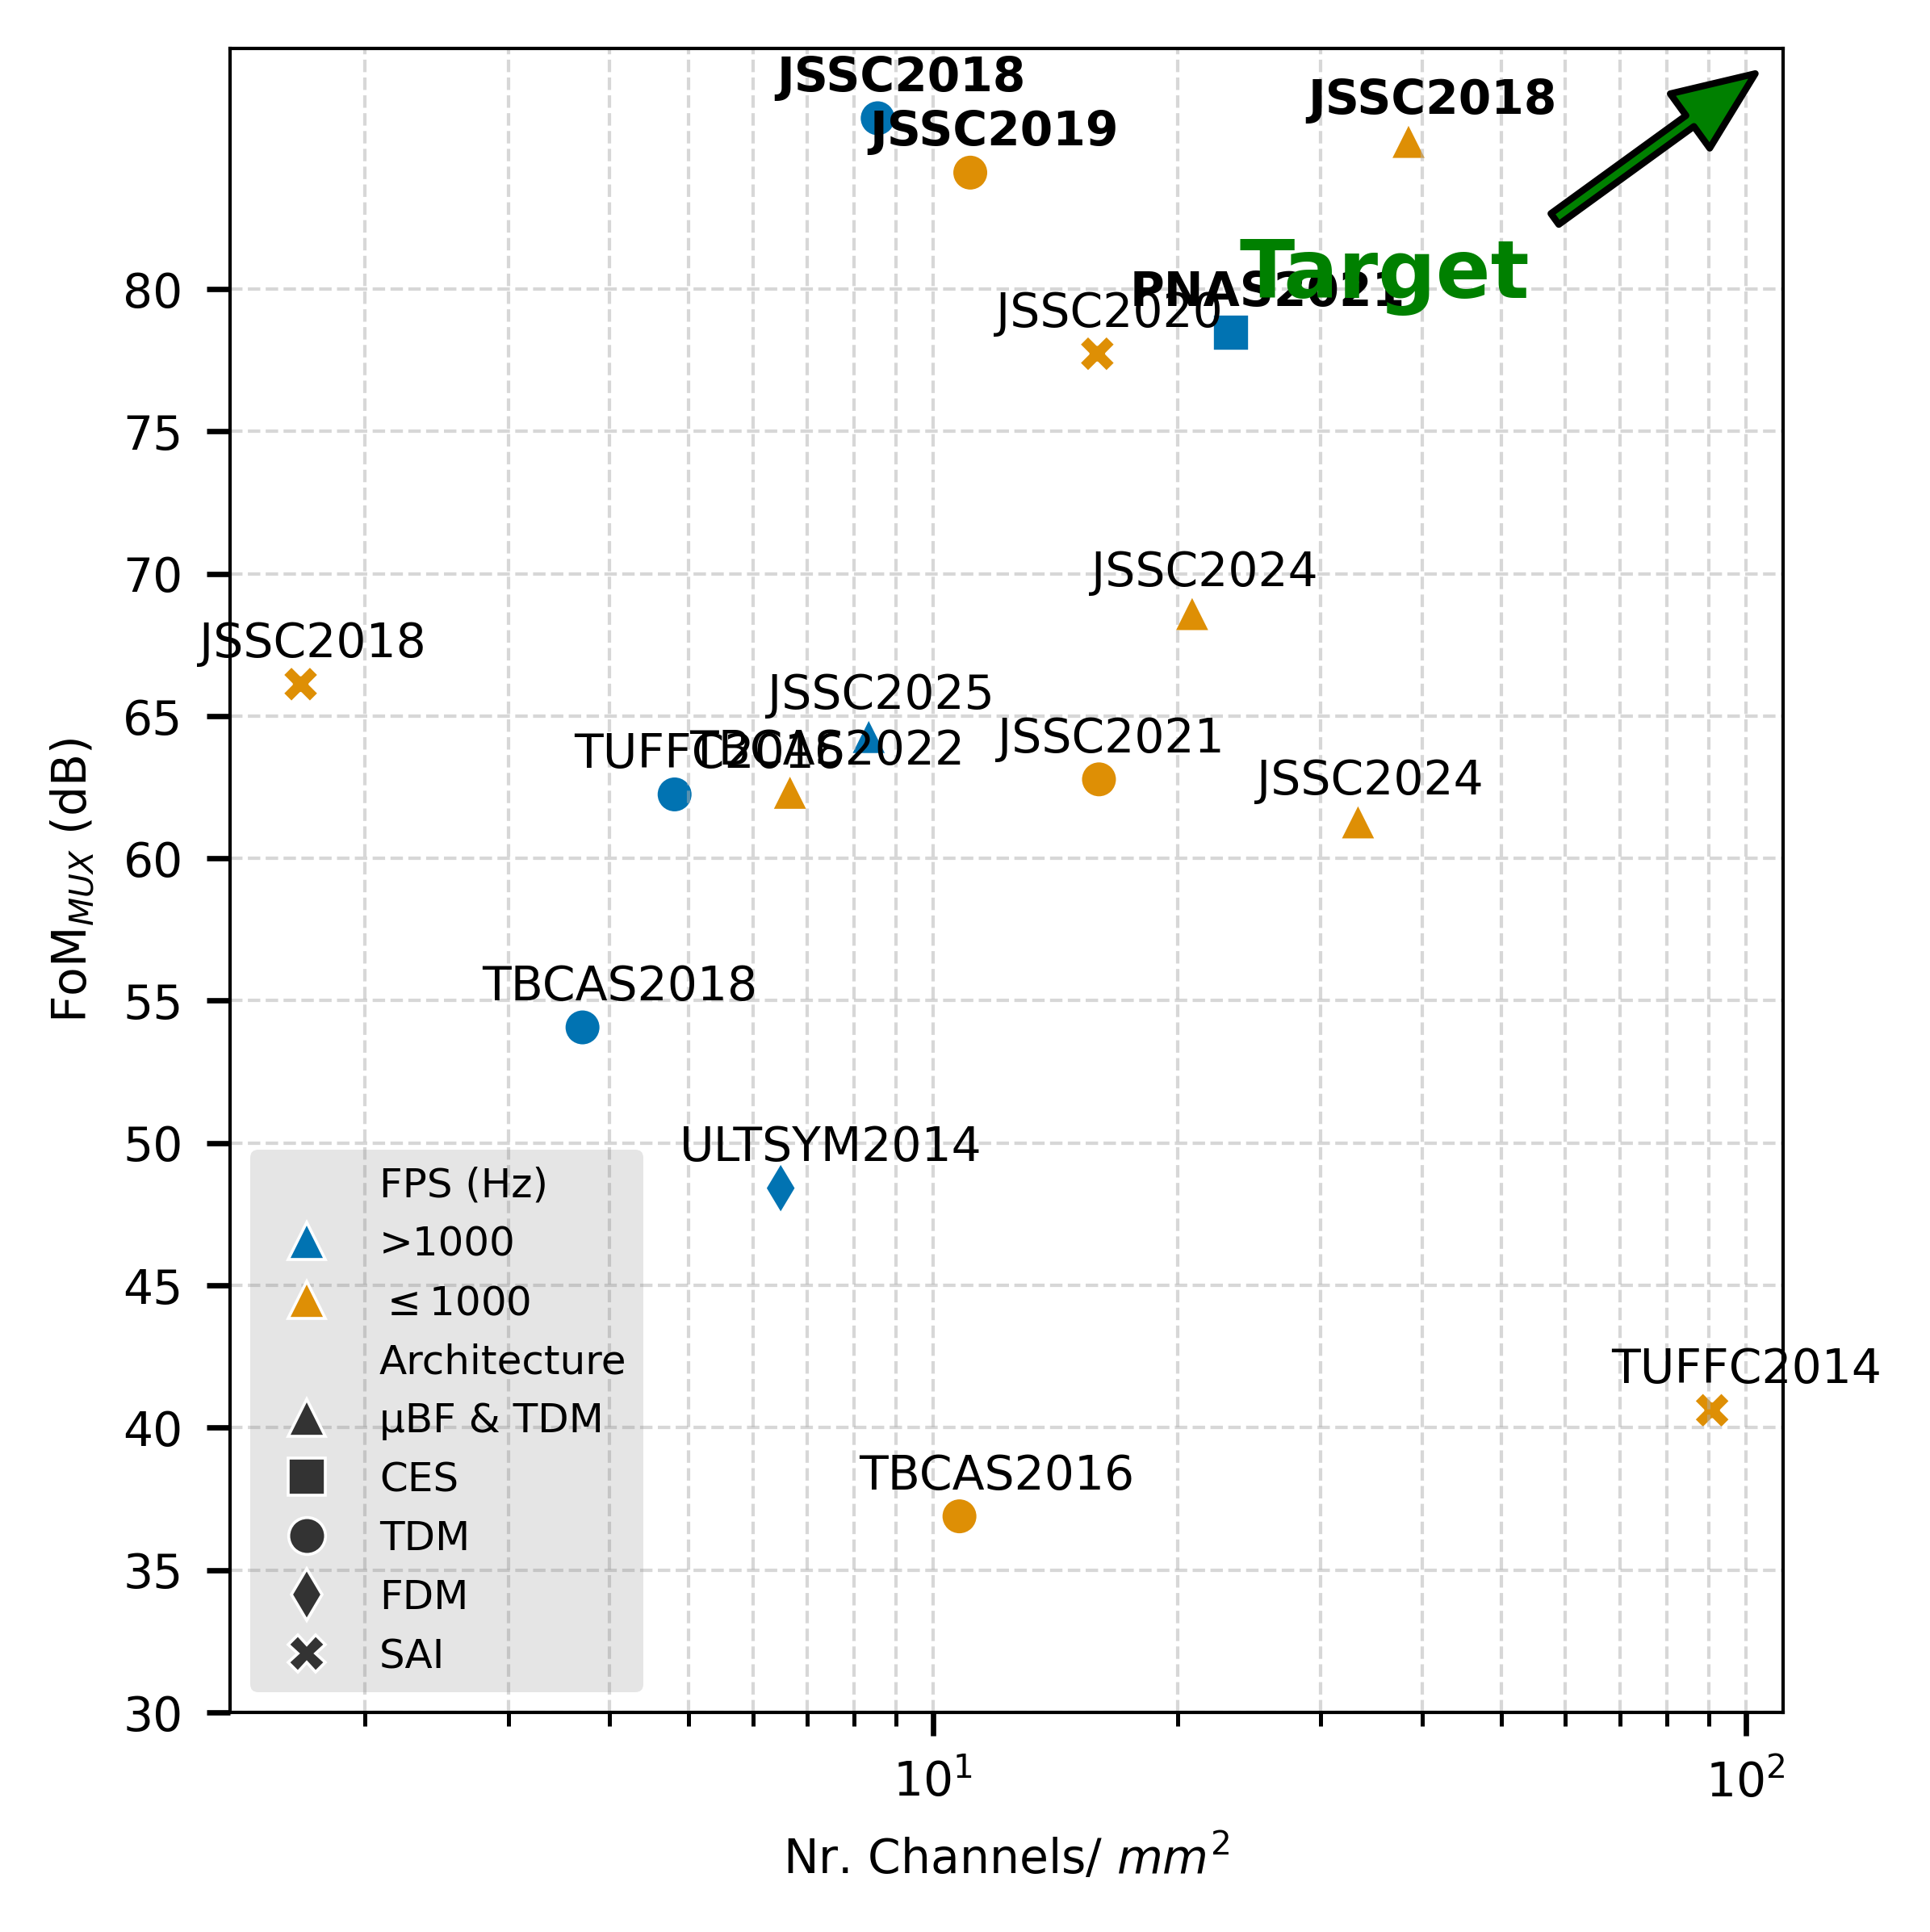

In [27]:
# plot voltage amplifiers versus TIA architectures, to observe how the choice of
# architecture affects overall performance of the main block of the AFE
fig, ax = plt.subplots(1,1, figsize=(4,4))
sns.scatterplot(
    data=afesurveydf,
    x='Nr. Channels/ $mm^2$',
    y='FoM$_{MUX}$ (dB)',
    hue='FPS (Hz)', # This is the column that distinguishes the classes
    style='Architecture',     # Controls shape/marker by class
    s=CUSTOM_DOT_SIZE,             # Sets the size of the dots
    markers=MARKER_STYLES,         # Assigns specific shapes to the classes
    palette='colorblind',         # Assigns specific colors to the classes
    ax=ax,
)

step_size = 5.0
num = int(50.0 / step_size)+1
ax.set_yticks(np.linspace(30.0, 80.0, num))
ax.set_xscale('log')

FOM_THRESHOLD = 78.0

for index, row in afesurveydf.iterrows():
    # 2. Check the threshold to determine text and weight
    if row['PaperID'] == np.nan: 
        continue
    display_text = row['PaperID']
    if row['FoM$_{MUX}$ (dB)'] > FOM_THRESHOLD:
        display_text += ''  # Append the custom string
        text_weight = 'bold'           # Make it bold
    else:
        text_weight = 'normal'         # Keep it regular
    if display_text != 'nan':
        ax.annotate(
            display_text,                     # The text to display
            xy=(row['Nr. Channels/ $mm^2$'], row['FoM$_{MUX}$ (dB)']),   # The exact coordinates of the dot
            xytext=(-15, 6),                           # The offset: (8 points right, 0 points up/down)
            textcoords='offset points',              # Tells matplotlib to use points for the offset
            ha='left',                               # Horizontal alignment
            va='center',                             # Vertical alignment (keeps it centered with the dot)
            size='medium',
            color='black',
            weight=text_weight
        )

# 1. Add the Target Arrow pointing to the top-left
ax.annotate(
    'Target', 
    xy=(0.99, 0.99),             # The point of the arrow (5% from left, 95% from bottom)
    xytext=(0.65, 0.85),         # The location of the text
    xycoords='axes fraction',    # Use the plot's bounding box, not the data scale
    textcoords='axes fraction',  
    fontsize=12,
    fontweight='bold',
    color='green',
    arrowprops=dict(
        facecolor='green',       # Arrow color
        shrink=0.05,             # Leaves a tiny gap between the text/edge and the arrow
        width=2,                 # Thickness of the arrow tail
        headwidth=10             # Thickness of the arrow head
    )
)

ax.grid(linestyle='--', alpha=0.5, which='both')
#ax.set_yscale('log')
ax.legend(title='',frameon=True, loc='lower left',facecolor='gray', framealpha=0.2, edgecolor='none', fontsize=6)
fig.tight_layout()

fig.savefig(dir/'afe_cmux_architecture_survey.pdf', dpi=300)